In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df= pd.read_csv("Reviews.csv")

In [3]:
df.head(1)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...


In [4]:
df.shape

(568454, 10)

In [5]:
df.dtypes

Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

In [6]:
df['Text'].values[0]

'I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.'

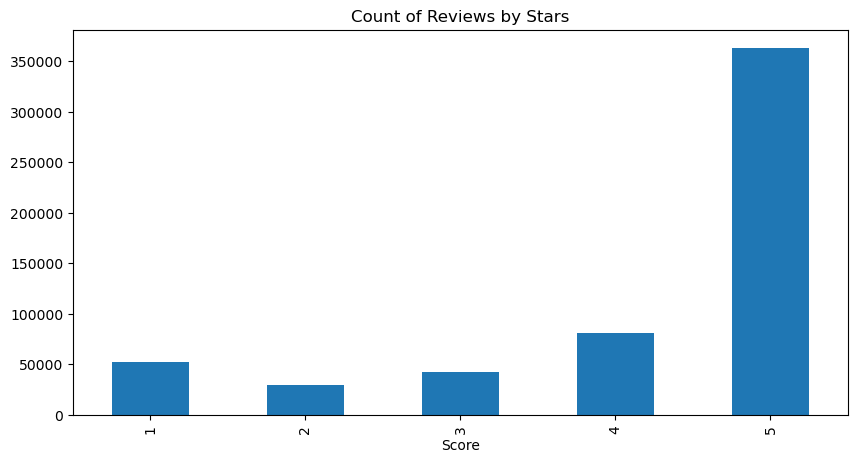

In [7]:
ax= df['Score'].value_counts().sort_index().plot(kind = 'bar', title= 'Count of Reviews by Stars', figsize = (10, 5)) 
ax.set_xlabel= ('Review Stars')
plt.show()

In [ ]:
example= df['Text'][50]
print(example)

In [9]:
nltk.word_tokenize(example)

['This',
 'oatmeal',
 'is',
 'not',
 'good',
 '.',
 'Its',
 'mushy',
 ',',
 'soft',
 ',',
 'I',
 'do',
 "n't",
 'like',
 'it',
 '.',
 'Quaker',
 'Oats',
 'is',
 'the',
 'way',
 'to',
 'go',
 '.']

In [10]:
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to C:\Users\sunny
[nltk_data]     kashyap\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\sunny kashyap\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [11]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
nltk.data.path.append(r"C:\Users\sunny kashyap\AppData\Roaming\nltk_data")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\sunny kashyap\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [12]:
from nltk.tokenize import word_tokenize
import nltk

text = df["Text"].iloc[0]
tokens = word_tokenize(text)

tagged = nltk.pos_tag(tokens)  
print(tagged)

[('I', 'PRP'), ('have', 'VBP'), ('bought', 'VBN'), ('several', 'JJ'), ('of', 'IN'), ('the', 'DT'), ('Vitality', 'NNP'), ('canned', 'VBD'), ('dog', 'RP'), ('food', 'NN'), ('products', 'NNS'), ('and', 'CC'), ('have', 'VBP'), ('found', 'VBN'), ('them', 'PRP'), ('all', 'DT'), ('to', 'TO'), ('be', 'VB'), ('of', 'IN'), ('good', 'JJ'), ('quality', 'NN'), ('.', '.'), ('The', 'DT'), ('product', 'NN'), ('looks', 'VBZ'), ('more', 'RBR'), ('like', 'IN'), ('a', 'DT'), ('stew', 'NN'), ('than', 'IN'), ('a', 'DT'), ('processed', 'JJ'), ('meat', 'NN'), ('and', 'CC'), ('it', 'PRP'), ('smells', 'VBZ'), ('better', 'RBR'), ('.', '.'), ('My', 'PRP$'), ('Labrador', 'NNP'), ('is', 'VBZ'), ('finicky', 'JJ'), ('and', 'CC'), ('she', 'PRP'), ('appreciates', 'VBZ'), ('this', 'DT'), ('product', 'NN'), ('better', 'JJR'), ('than', 'IN'), ('most', 'JJS'), ('.', '.')]


In [13]:
nltk.pos_tag(tokens)
tagged[:10]

[('I', 'PRP'),
 ('have', 'VBP'),
 ('bought', 'VBN'),
 ('several', 'JJ'),
 ('of', 'IN'),
 ('the', 'DT'),
 ('Vitality', 'NNP'),
 ('canned', 'VBD'),
 ('dog', 'RP'),
 ('food', 'NN')]

In [14]:
import nltk
nltk.download('maxent_ne_chunker_tab ')
nltk.download('words')

[nltk_data] Error loading maxent_ne_chunker_tab : Package
[nltk_data]     'maxent_ne_chunker_tab ' not found in index
[nltk_data] Downloading package words to C:\Users\sunny
[nltk_data]     kashyap\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [15]:
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

(S
  I/PRP
  have/VBP
  bought/VBN
  several/JJ
  of/IN
  the/DT
  (ORGANIZATION Vitality/NNP)
  canned/VBD
  dog/RP
  food/NN
  products/NNS
  and/CC
  have/VBP
  found/VBN
  them/PRP
  all/DT
  to/TO
  be/VB
  of/IN
  good/JJ
  quality/NN
  ./.
  The/DT
  product/NN
  looks/VBZ
  more/RBR
  like/IN
  a/DT
  stew/NN
  than/IN
  a/DT
  processed/JJ
  meat/NN
  and/CC
  it/PRP
  smells/VBZ
  better/RBR
  ./.
  My/PRP$
  (ORGANIZATION Labrador/NNP)
  is/VBZ
  finicky/JJ
  and/CC
  she/PRP
  appreciates/VBZ
  this/DT
  product/NN
  better/JJR
  than/IN
  most/JJS
  ./.)


In [16]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to C:\Users\sunny
[nltk_data]     kashyap\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [17]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

In [18]:
sia = SentimentIntensityAnalyzer()

In [19]:
sia.polarity_scores('I am so happy')

{'neg': 0.0, 'neu': 0.334, 'pos': 0.666, 'compound': 0.6115}

In [20]:
sia.polarity_scores('This is the worst thing ever')

{'neg': 0.451, 'neu': 0.549, 'pos': 0.0, 'compound': -0.6249}

In [21]:
sia.polarity_scores(example)

{'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

In [22]:
from tqdm import tqdm

In [23]:
res={}
for i, row in tqdm(df.iterrows(), total= len(df)):
    text = row['Text']
    myid = row['Id']
    res[myid]= sia.polarity_scores(text)

100%|██████████| 568454/568454 [11:05<00:00, 854.10it/s] 


In [35]:
vaders = pd.DataFrame(res).T
vaders= vaders.reset_index().rename(columns = {'index' : 'Id'})
vaders= vaders.merge(df, how= 'left')

In [36]:
vaders.head(5)

,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


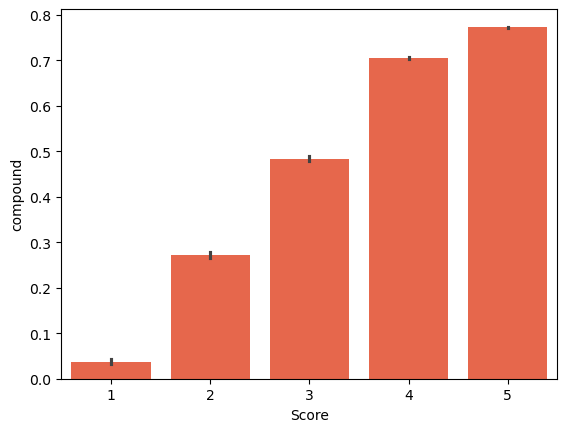

In [37]:
sns.barplot(data = vaders, x= 'Score', y= 'compound', color= '#FF5733')
ax.set_title('Compound Score by Amazon Star Review')
plt.show()

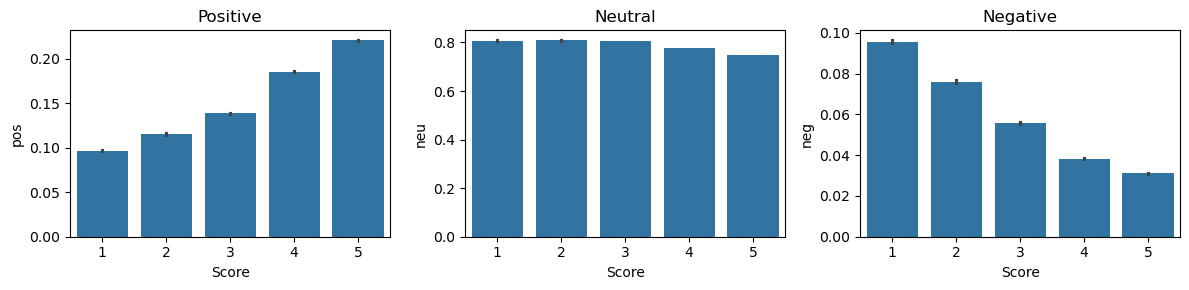

In [38]:
fig, axs= plt.subplots(1, 3, figsize= (12,3))
sns.barplot(data = vaders, x='Score', y='pos', ax=axs[0])
sns.barplot(data = vaders, x='Score', y='neu', ax=axs[1])
sns.barplot(data = vaders, x='Score', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative') 
plt.tight_layout()
plt.show()

In [39]:
pip install transformers

In [40]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [47]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [51]:
MODEL = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [56]:
text = df["Text"].iloc[0]

inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)

In [60]:
encoded_text = tokenizer(text, return_tensors= 'pt')
output= model(**encoded_text)
scores= output[0][0].detach().numpy()
scores= softmax(scores)
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}
print(scores_dict)

{'roberta_neg': 0.009624195, 'roberta_neu': 0.049980264, 'roberta_pos': 0.9403955}


In [61]:
def polarity_scores_roberta(text):
     encoded_text = tokenizer(text, return_tensors= 'pt')
     output= model(**encoded_text)
     scores= output[0][0].detach().numpy()
     scores= softmax(scores)
     scores_dict = {
         'roberta_neg' : scores[0],
         'roberta_neu' : scores[1],
         'roberta_pos' : scores[2]
     }
     return scores_dict

In [ ]:
res={}
for i, row in tqdm(df.iterrows(), total= len(df)):
    try:
        text = row['Text']
        myid = row['Id']
        vader_result= sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result, **roberta_result}
        res[myid] = both 
    except RuntimeError:
        print(f'Broke for id {myid}')

  0%|          | 84/568454 [00:08<12:20:39, 12.79it/s]

Broke for id 83


  0%|          | 189/568454 [00:18<13:05:29, 12.06it/s]

Broke for id 187


  0%|          | 530/568454 [00:59<16:18:48,  9.67it/s]

...

  2%|▏         | 8758/568454 [17:21<13:15:35, 11.72it/s]

Broke for id 8757


  2%|▏         | 8937/568454 [17:40<10:26:53, 14.88it/s]

Broke for id 8935


  2%|▏         | 9227/568454 [18:07<12:47:53, 12.14it/s]

In [68]:
both

{'neg': 0.0,
 'neu': 0.695,
 'pos': 0.305,
 'compound': 0.9441,
 'roberta_neg': 0.009624195,
 'roberta_neu': 0.049980264,
 'roberta_pos': 0.9403955}

In [ ]:
result_df = pd.DataFrame(res).T
result_df = result_df.reset_index().rename(columns = {'index': 'Id'})
result_df = result_df.merge(df, how = 'left')

In [58]:
sentiment_class = ['negative', 'neutral', 'positive']
predicted_sentiment = sentiment_class[probs.argmax()]
print(f"Predicted sentiment: {predicted_sentiment}")

Predicted sentiment: positive
